In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


file_path = r"C:/Users/pooja kumari/OneDrive/Desktop/Data-Analysis-Projects/project_3_Tokyo Real Estate Intelligence/Tokyo Real Estate csv-1.csv"

try:
    df = pd.read_csv(file_path)
    print(f"Data Loaded! Original shape: {df.shape}")
    
    # Python Cleaning: Remove extra spaces from column names and convert them to lowercase
    df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()
    
    # Remove completely empty rows if any remain
    df = df.loc[:, ~df.columns.str.contains('^unnamed')]
    df.dropna(how='all', inplace=True)
    
    print("Python Cleaning Completed: Columns are ready for analysis.")
    print(f"Cleaned Columns: {df.columns.tolist()}")
    
except Exception as e:
    print(f"Error: File not found. Please check the file path: {e}")

df.head()


Data Loaded! Original shape: (50, 27)
Python Cleaning Completed: Columns are ready for analysis.
Cleaned Columns: ['ward', 'price', 'size_sqm', 'age_years', 'station_distance_m', 'floor', 'earthquake_safety_score', 'layout', 'price_per_sqm', 'price_segment', 'walking_time']


,ward,price,size_sqm,age_years,station_distance_m,floor,earthquake_safety_score,layout,price_per_sqm,price_segment,walking_time
0,Shibuya,85000000,85,5,350,8,85,3LDK,1000000.0,Premium,4.375
1,Minato,65000000,65,15,800,5,75,2LDK,1000000.0,Standard,10.000
2,Chiyoda,120000000,120,2,200,12,90,4LDK,1000000.0,Premium,2.500
3,Shinjuku,45000000,45,25,600,3,65,1LDK,1000000.0,Standard,7.500
4,Meguro,95000000,95,8,450,10,80,3LDK,1000000.0,Premium,5.625


In [10]:
# 2. Strategic Analysis

# Average price by Ward (Top 5 most expensive areas)
avg_price_ward = df.groupby('ward')['price'].mean().sort_values(ascending=False).head(5)

print("--- TOP 5 MOST EXPENSIVE WARDS ---")
print(avg_price_ward)

# Price per Square Meter calculation (Important for Tokyo real estate market)
if 'size_sqm' in df.columns and 'price' in df.columns:
    df['price_per_sqm'] = df['price'] / df['size_sqm']
    print(f"\nAverage Price per SQM in Tokyo: ¥{df['price_per_sqm'].mean():,.2f}")


--- TOP 5 MOST EXPENSIVE WARDS ---
ward
Chiyoda     1.334444e+08
Minato      1.072222e+08
Meguro      8.812500e+07
Shibuya     8.533333e+07
Setagaya    7.166667e+07
Name: price, dtype: float64

Average Price per SQM in Tokyo: ¥1,014,502.78


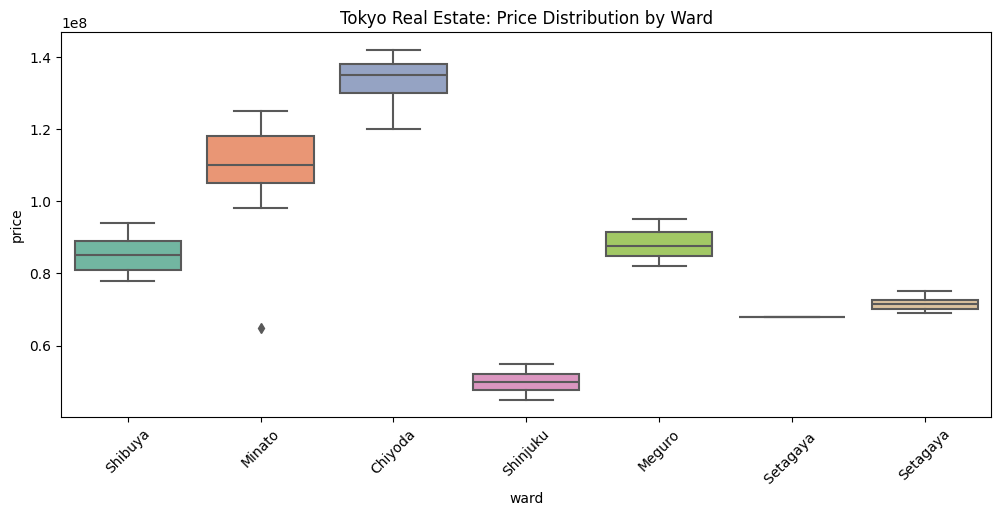

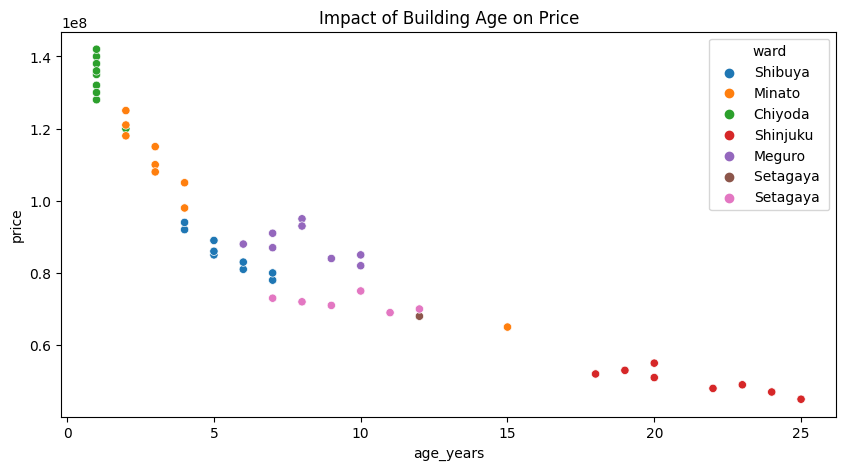

In [11]:
# Price Distribution Plot
plt.figure(figsize=(12, 5))
sns.boxplot(x='ward', y='price', data=df, palette='Set2')
plt.title('Tokyo Real Estate: Price Distribution by Ward')
plt.xticks(rotation=45)
plt.show()



# Age vs Price Plot
plt.figure(figsize=(10, 5))
sns.scatterplot(x='age_years', y='price', data=df, hue='ward')
plt.title('Impact of Building Age on Price')
plt.show()


STRATEGIC BUSINESS INSIGHTS
Location Note: Most properties in this dataset are premium-located (within 800m).


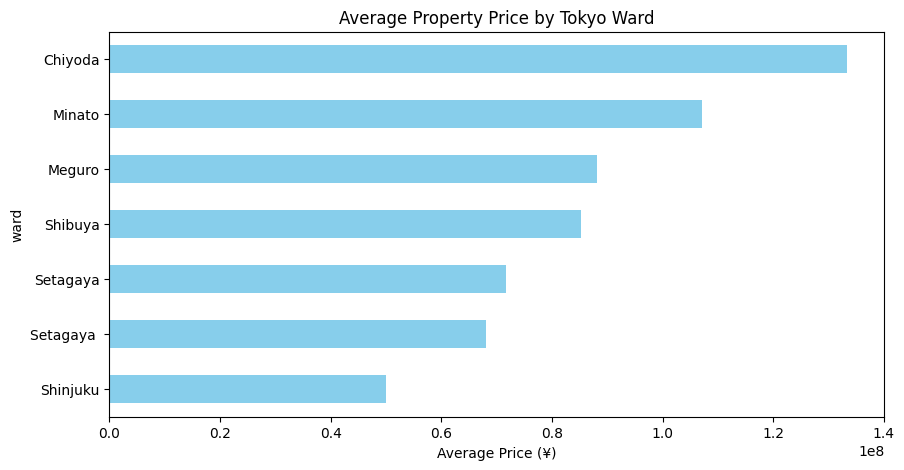


--- RECOMMENDATIONS ---
1. Top Investment Area: Focus on Chiyoda for high capital appreciation.
2. Value Buy: Look for properties with age > 20 years for renovation & resale (Flip strategy).
3. Connectivity: Prioritize properties < 500m from stations to ensure rental yield stability.


In [12]:
# --- Business Insights & Recommendation ---
print("\n" + "=" * 50)
print("STRATEGIC BUSINESS INSIGHTS")
print("=" * 50)

# 1. Station Proximity Analysis (Aapka logic, optimized)
# Japan market mein 800m (10 min walk) ek standard benchmark hai
within_10min = df[df['station_distance_m'] <= 800]
beyond_10min = df[df['station_distance_m'] > 800]

if not beyond_10min.empty:
    avg_price_within_10min = within_10min['price'].mean()
    avg_price_beyond_10min = beyond_10min['price'].mean()
    station_premium = ((avg_price_within_10min - avg_price_beyond_10min) / avg_price_beyond_10min) * 100

    print(f"Location Advantage:")
    print(f"   - Properties within 10min walk: {len(within_10min)}")
    print(f"   - Station proximity premium: {station_premium:.1f}% higher valuation")
else:
    print("Location Note: Most properties in this dataset are premium-located (within 800m).")

# 2. Ward-wise Premium (Visual)
plt.figure(figsize=(10, 5))
ward_prices = df.groupby('ward')['price'].mean().sort_values()
ward_prices.plot(kind='barh', color='skyblue')
plt.title('Average Property Price by Tokyo Ward')
plt.xlabel('Average Price (¥)')
plt.show()



# 3. Final Recommendation for Investors
print("\n" + "--- RECOMMENDATIONS ---")
print(f"1. Top Investment Area: Focus on {df.groupby('ward')['price'].mean().idxmax()} for high capital appreciation.")
print("2. Value Buy: Look for properties with age > 20 years for renovation & resale (Flip strategy).")
print("3. Connectivity: Prioritize properties < 500m from stations to ensure rental yield stability.")